# Phase 5 — Financial Risk & Early-Warning Engine

This notebook develops MonteCore's financial risk and early-warning
component.

The objective is to identify customers exhibiting indicators of
financial stress or increasing financial risk and convert model outputs
into interpretable risk evidence for downstream investigation.

The pipeline includes:

- financial risk data validation and EDA
- risk-oriented feature engineering
- supervised risk modelling
- model evaluation
- behavioural stress indicators
- interpretable risk tiers
- investigation-ready risk outputs
- model persistence and validation

In [40]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(
    "../data/raw/credit_risk/default of credit card clients.xls"
)

credit_df = pd.read_excel(
    data_path,
    header=1
)

print("Dataset loaded successfully.")
print("Shape:", credit_df.shape)

credit_df.head()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [2]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(
    "../data/raw/credit_risk/default of credit card clients.xls"
)

credit_df = pd.read_excel(
    data_path,
    header=1
)

print("Dataset loaded successfully.")
print("Shape:", credit_df.shape)

credit_df.head()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
print("Columns:")
for i, col in enumerate(credit_df.columns, start=1):
    print(f"{i}. {col}")

print("\nDataset information:")
credit_df.info()

print("\nTarget distribution:")
print(credit_df["default payment next month"].value_counts())

print("\nTarget percentages:")
print(
    credit_df["default payment next month"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Columns:
1. ID
2. LIMIT_BAL
3. SEX
4. EDUCATION
5. MARRIAGE
6. AGE
7. PAY_0
8. PAY_2
9. PAY_3
10. PAY_4
11. PAY_5
12. PAY_6
13. BILL_AMT1
14. BILL_AMT2
15. BILL_AMT3
16. BILL_AMT4
17. BILL_AMT5
18. BILL_AMT6
19. PAY_AMT1
20. PAY_AMT2
21. PAY_AMT3
22. PAY_AMT4
23. PAY_AMT5
24. PAY_AMT6
25. default payment next month

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8

In [5]:
print("Dataset shape:", credit_df.shape)

print("\nTotal missing values:")
print(credit_df.isna().sum().sum())

print("\nDuplicate rows:")
print(credit_df.duplicated().sum())

print("\nDuplicate IDs:")
print(credit_df["ID"].duplicated().sum())

print("\nUnique values in categorical / repayment columns:")

check_columns = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in check_columns:
    print(f"\n{col}:")
    print(sorted(credit_df[col].unique()))

Dataset shape: (30000, 25)

Total missing values:
0

Duplicate rows:
0

Duplicate IDs:
0

Unique values in categorical / repayment columns:

SEX:
[np.int64(1), np.int64(2)]

EDUCATION:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

MARRIAGE:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

PAY_0:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_2:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_3:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_4:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_5:
[np.int64(-2), np.int64(-1), np.int

In [6]:
print("EDUCATION distribution")
print("----------------------")
print(credit_df["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE distribution")
print("---------------------")
print(credit_df["MARRIAGE"].value_counts().sort_index())

print("\nRepayment status distributions")
print("------------------------------")

pay_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

for col in pay_columns:
    print(f"\n{col}")
    print(credit_df[col].value_counts().sort_index())

EDUCATION distribution
----------------------
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE distribution
---------------------
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Repayment status distributions
------------------------------

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8      

In [7]:
# Preserve the original loaded dataset
df = credit_df.copy()

# Rename target to something easier to work with
df = df.rename(
    columns={"default payment next month": "DefaultNextMonth"}
)

# Consolidate undocumented / rare education categories into "Other"
# 1 = Graduate School
# 2 = University
# 3 = High School
# 4 = Other
df["EDUCATION"] = df["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Consolidate undocumented marriage code into "Other"
# 1 = Married
# 2 = Single
# 3 = Other
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0: 3
})

print("Working dataset shape:", df.shape)

print("\nCleaned EDUCATION distribution:")
print(df["EDUCATION"].value_counts().sort_index())

print("\nCleaned MARRIAGE distribution:")
print(df["MARRIAGE"].value_counts().sort_index())

print("\nTarget:")
print(df["DefaultNextMonth"].value_counts())

Working dataset shape: (30000, 25)

Cleaned EDUCATION distribution:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Cleaned MARRIAGE distribution:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

Target:
DefaultNextMonth
0    23364
1     6636
Name: count, dtype: int64


In [8]:
financial_columns = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df[financial_columns].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.08,71173.77,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.15,69349.39,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.95,64332.86,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.40,60797.16,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.76,59554.11,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.58,16563.28,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.16,23040.87,0.0,833.00,2009.0,5000.00,1684259.0


## Financial-Risk Feature Engineering

Raw monthly credit-card history is transformed into behavioural features
that summarize customer financial stress, repayment behaviour, credit
utilization, and recent deterioration.

In [9]:
bill_columns = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

payment_columns = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

df["AverageBillAmount"] = df[bill_columns].mean(axis=1)

df["AveragePaymentAmount"] = df[payment_columns].mean(axis=1)

df[
    [
        "LIMIT_BAL",
        "AverageBillAmount",
        "AveragePaymentAmount",
        "DefaultNextMonth"
    ]
].head(10)

,LIMIT_BAL,AverageBillAmount,AveragePaymentAmount,DefaultNextMonth
0,20000,1284.000000,114.833333,1
1,120000,2846.166667,833.333333,1
2,90000,16942.166667,1836.333333,0
3,50000,38555.666667,1398.000000,0
4,50000,18223.166667,9841.500000,0
5,50000,39685.666667,1295.333333,0
6,500000,454099.166667,30126.500000,0
7,100000,2247.666667,798.500000,0
8,140000,10868.666667,1126.833333,0
9,20000,4486.500000,2354.833333,0


In [10]:
df["CreditUtilization"] = (
    df["AverageBillAmount"] / df["LIMIT_BAL"]
)

print("Credit utilization summary")
print("--------------------------")
print(df["CreditUtilization"].describe().round(3))

print("\nFirst 10 customers:")
df[
    [
        "LIMIT_BAL",
        "AverageBillAmount",
        "CreditUtilization",
        "DefaultNextMonth"
    ]
].head(10)

Credit utilization summary
--------------------------
count    30000.000
mean         0.373
std          0.352
min         -0.233
25%          0.030
50%          0.285
75%          0.688
max          5.364
Name: CreditUtilization, dtype: float64

First 10 customers:


,LIMIT_BAL,AverageBillAmount,CreditUtilization,DefaultNextMonth
0,20000,1284.000000,0.064200,1
1,120000,2846.166667,0.023718,1
2,90000,16942.166667,0.188246,0
3,50000,38555.666667,0.771113,0
4,50000,18223.166667,0.364463,0
5,50000,39685.666667,0.793713,0
6,500000,454099.166667,0.908198,0
7,100000,2247.666667,0.022477,0
8,140000,10868.666667,0.077633,0
9,20000,4486.500000,0.224325,0


In [11]:
# Use positive bill balances for the payment-to-bill calculation.
# Negative/zero bills represent credit balances or no amount due,
# so they should not form the denominator.

df["AveragePositiveBillAmount"] = (
    df[bill_columns]
    .clip(lower=0)
    .mean(axis=1)
)

df["PaymentToBillRatio"] = np.where(
    df["AveragePositiveBillAmount"] > 0,
    df["AveragePaymentAmount"] / df["AveragePositiveBillAmount"],
    0
)

print("Payment-to-bill ratio summary")
print("-----------------------------")
print(df["PaymentToBillRatio"].describe().round(3))

print("\nFirst 10 customers:")

df[
    [
        "AverageBillAmount",
        "AveragePaymentAmount",
        "AveragePositiveBillAmount",
        "PaymentToBillRatio",
        "DefaultNextMonth"
    ]
].head(10)

Payment-to-bill ratio summary
-----------------------------
count    30000.000
mean         0.482
std          5.613
min          0.000
25%          0.041
50%          0.086
75%          0.597
max        797.000
Name: PaymentToBillRatio, dtype: float64

First 10 customers:


,AverageBillAmount,AveragePaymentAmount,AveragePositiveBillAmount,PaymentToBillRatio,DefaultNextMonth
0,1284.000000,114.833333,1284.000000,0.089434,1
1,2846.166667,833.333333,2846.166667,0.292791,1
2,16942.166667,1836.333333,16942.166667,0.108388,0
3,38555.666667,1398.000000,38555.666667,0.036259,0
4,18223.166667,9841.500000,18223.166667,0.540054,0
5,39685.666667,1295.333333,39685.666667,0.032640,0
6,454099.166667,30126.500000,454099.166667,0.066343,0
7,2247.666667,798.500000,2274.166667,0.351118,0
8,10868.666667,1126.833333,10868.666667,0.103677,0
9,4486.500000,2354.833333,4486.500000,0.524871,0


In [12]:
pay_status_columns = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

# Number of months where the customer was at least 1 month late
df["DelayedPaymentMonths"] = (
    df[pay_status_columns] >= 1
).sum(axis=1)

# Most severe delay observed across the six-month history
# Negative/on-time codes are treated as zero delay for this feature
df["MaxPaymentDelay"] = (
    df[pay_status_columns]
    .clip(lower=0)
    .max(axis=1)
)

# Most recent repayment status
df["RecentPaymentDelay"] = (
    df["PAY_0"]
    .clip(lower=0)
)

print("Delayed payment months distribution")
print("-----------------------------------")
print(df["DelayedPaymentMonths"].value_counts().sort_index())

print("\nMaximum payment delay distribution")
print("----------------------------------")
print(df["MaxPaymentDelay"].value_counts().sort_index())

print("\nRecent payment delay distribution")
print("---------------------------------")
print(df["RecentPaymentDelay"].value_counts().sort_index())

Delayed payment months distribution
-----------------------------------
DelayedPaymentMonths
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64

Maximum payment delay distribution
----------------------------------
MaxPaymentDelay
0    19931
1     1689
2     7187
3      789
4      218
5       69
6       25
7       67
8       25
Name: count, dtype: int64

Recent payment delay distribution
---------------------------------
RecentPaymentDelay
0    23182
1     3688
2     2667
3      322
4       76
5       26
6       11
7        9
8       19
Name: count, dtype: int64


In [13]:
# Convert repayment status into delinquency severity:
# negative/on-time values become 0, positive values retain delay severity.

recent_delay = (
    df[["PAY_0", "PAY_2", "PAY_3"]]
    .clip(lower=0)
    .mean(axis=1)
)

older_delay = (
    df[["PAY_4", "PAY_5", "PAY_6"]]
    .clip(lower=0)
    .mean(axis=1)
)

# Positive = repayment behaviour has deteriorated recently
# Negative = repayment behaviour has improved recently
df["RepaymentDeterioration"] = recent_delay - older_delay

# Simple interpretable warning flag
df["RepaymentWorseningFlag"] = (
    df["RepaymentDeterioration"] > 0
).astype(int)

print("Repayment deterioration summary")
print("--------------------------------")
print(df["RepaymentDeterioration"].describe().round(3))

print("\nRepayment worsening flag")
print("------------------------")
print(df["RepaymentWorseningFlag"].value_counts())

print("\nPercentage showing worsening repayment behaviour:")
print(
    round(df["RepaymentWorseningFlag"].mean() * 100, 2),
    "%"
)

Repayment deterioration summary
--------------------------------
count    30000.000
mean         0.091
std          0.574
min         -5.333
25%          0.000
50%          0.000
75%          0.000
max          3.333
Name: RepaymentDeterioration, dtype: float64

Repayment worsening flag
------------------------
RepaymentWorseningFlag
0    23743
1     6257
Name: count, dtype: int64

Percentage showing worsening repayment behaviour:
20.86 %


In [14]:
recent_bill_avg = (
    df[["BILL_AMT1", "BILL_AMT2", "BILL_AMT3"]]
    .mean(axis=1)
)

older_bill_avg = (
    df[["BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]]
    .mean(axis=1)
)

df["BillAmountTrend"] = recent_bill_avg - older_bill_avg

df["IncreasingDebtFlag"] = (
    df["BillAmountTrend"] > 0
).astype(int)

print("Bill amount trend summary")
print("-------------------------")
print(df["BillAmountTrend"].describe().round(2))

print("\nIncreasing debt flag")
print("--------------------")
print(df["IncreasingDebtFlag"].value_counts())

print("\nPercentage with increasing recent bill balances:")
print(
    round(df["IncreasingDebtFlag"].mean() * 100, 2),
    "%"
)

Bill amount trend summary
-------------------------
count     30000.00
mean       8323.15
std       29831.16
min     -291275.00
25%       -1899.75
50%         658.67
75%       12647.33
max      432428.33
Name: BillAmountTrend, dtype: float64

Increasing debt flag
--------------------
IncreasingDebtFlag
1    16957
0    13043
Name: count, dtype: int64

Percentage with increasing recent bill balances:
56.52 %


In [15]:
recent_payment_avg = (
    df[["PAY_AMT1", "PAY_AMT2", "PAY_AMT3"]]
    .mean(axis=1)
)

older_payment_avg = (
    df[["PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]]
    .mean(axis=1)
)

df["PaymentAmountTrend"] = (
    recent_payment_avg - older_payment_avg
)

# Flag customers whose recent payments have decreased
df["DecreasingPaymentFlag"] = (
    df["PaymentAmountTrend"] < 0
).astype(int)

print("Payment amount trend summary")
print("----------------------------")
print(df["PaymentAmountTrend"].describe().round(2))

print("\nDecreasing payment flag")
print("-----------------------")
print(df["DecreasingPaymentFlag"].value_counts())

print("\nPercentage with decreasing recent payments:")
print(
    round(df["DecreasingPaymentFlag"].mean() * 100, 2),
    "%"
)

Payment amount trend summary
----------------------------
count     30000.00
mean        656.49
std       13892.58
min     -177931.33
25%        -316.67
50%         403.33
75%        1513.08
max      730688.67
Name: PaymentAmountTrend, dtype: float64

Decreasing payment flag
-----------------------
DecreasingPaymentFlag
0    20577
1     9423
Name: count, dtype: int64

Percentage with decreasing recent payments:
31.41 %


In [16]:
engineered_features = [
    "AverageBillAmount",
    "AveragePaymentAmount",
    "CreditUtilization",
    "PaymentToBillRatio",
    "DelayedPaymentMonths",
    "MaxPaymentDelay",
    "RecentPaymentDelay",
    "RepaymentDeterioration",
    "RepaymentWorseningFlag",
    "BillAmountTrend",
    "IncreasingDebtFlag",
    "PaymentAmountTrend",
    "DecreasingPaymentFlag"
]

risk_comparison = (
    df.groupby("DefaultNextMonth")[engineered_features]
    .mean()
    .T
)

risk_comparison.columns = [
    "Non_Default_Mean",
    "Default_Mean"
]

risk_comparison["Default_vs_NonDefault_Ratio"] = (
    risk_comparison["Default_Mean"]
    / risk_comparison["Non_Default_Mean"]
)

risk_comparison.round(3)

,Non_Default_Mean,Default_Mean,Default_vs_NonDefault_Ratio
AverageBillAmount,45404.818,43470.493,0.957
AveragePaymentAmount,5828.237,3328.216,0.571
CreditUtilization,0.351,0.449,1.279
PaymentToBillRatio,0.524,0.334,0.638
DelayedPaymentMonths,0.504,1.996,3.959
MaxPaymentDelay,0.470,1.428,3.037
RecentPaymentDelay,0.196,0.922,4.698
RepaymentDeterioration,0.052,0.231,4.475
RepaymentWorseningFlag,0.155,0.398,2.566
BillAmountTrend,8687.050,7041.934,0.811


In [17]:
df["FinancialStressIndicatorCount"] = (
    (df["CreditUtilization"] >= 0.75).astype(int)
    + (df["PaymentToBillRatio"] < 0.10).astype(int)
    + (df["DelayedPaymentMonths"] >= 2).astype(int)
    + (df["RecentPaymentDelay"] >= 1).astype(int)
    + (df["RepaymentWorseningFlag"] == 1).astype(int)
)

print("Financial stress indicator distribution")
print("---------------------------------------")
print(
    df["FinancialStressIndicatorCount"]
    .value_counts()
    .sort_index()
)

print("\nDefault rate by number of stress indicators")
print("-------------------------------------------")

stress_default_rate = (
    df.groupby("FinancialStressIndicatorCount")["DefaultNextMonth"]
    .agg(["count", "mean"])
)

stress_default_rate["DefaultRatePercent"] = (
    stress_default_rate["mean"] * 100
)

print(
    stress_default_rate[
        ["count", "DefaultRatePercent"]
    ].round(2)
)

Financial stress indicator distribution
---------------------------------------
FinancialStressIndicatorCount
0    10703
1     8058
2     5370
3     2748
4     2046
5     1075
Name: count, dtype: int64

Default rate by number of stress indicators
-------------------------------------------
                               count  DefaultRatePercent
FinancialStressIndicatorCount                           
0                              10703               11.52
1                               8058               13.73
2                               5370               20.22
3                               2748               51.24
4                               2046               59.73
5                               1075               54.05


## 5C — Financial Risk Modelling

A supervised classification model is trained to estimate the probability
that a customer will default in the following month.

Logistic Regression is first used as an interpretable baseline before
comparison with a more powerful tree-based model.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

model_features = [
    # Core customer / credit information
    "LIMIT_BAL",
    "AGE",

    # Repayment history
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    # Engineered financial behaviour
    "AverageBillAmount",
    "AveragePaymentAmount",
    "CreditUtilization",
    "PaymentToBillRatio",
    "DelayedPaymentMonths",
    "MaxPaymentDelay",
    "RecentPaymentDelay",
    "RepaymentDeterioration",
    "BillAmountTrend",
    "PaymentAmountTrend",
    "FinancialStressIndicatorCount"
]

X = df[model_features].copy()
y = df["DefaultNextMonth"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used:")
for feature in model_features:
    print("-", feature)

print("\nMissing values:", X.isna().sum().sum())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Feature matrix shape: (30000, 19)
Target shape: (30000,)

Features used:
- LIMIT_BAL
- AGE
- PAY_0
- PAY_2
- PAY_3
- PAY_4
- PAY_5
- PAY_6
- AverageBillAmount
- AveragePaymentAmount
- CreditUtilization
- PaymentToBillRatio
- DelayedPaymentMonths
- MaxPaymentDelay
- RecentPaymentDelay
- RepaymentDeterioration
- BillAmountTrend
- PaymentAmountTrend
- FinancialStressIndicatorCount

Missing values: 0

Target distribution:
DefaultNextMonth
0    23364
1     6636
Name: count, dtype: int64

Target percentage:
DefaultNextMonth
0    77.88
1    22.12
Name: proportion, dtype: float64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training set shape: (24000, 19)
Test set shape: (6000, 19)

Training target distribution:
DefaultNextMonth
0    77.88
1    22.12
Name: proportion, dtype: float64

Test target distribution:
DefaultNextMonth
0    77.88
1    22.12
Name: proportion, dtype: float64


In [20]:
scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to unseen test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nApproximate training mean:")
print(round(X_train_scaled.mean(), 4))

print("\nApproximate training standard deviation:")
print(round(X_train_scaled.std(), 4))

Scaled training shape: (24000, 19)
Scaled test shape: (6000, 19)

Approximate training mean:
-0.0

Approximate training standard deviation:
1.0


In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# Predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Probability that each customer defaults
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression trained successfully.")

print("\nPredicted class distribution:")
print(
    pd.Series(y_pred_logistic)
    .value_counts()
    .sort_index()
)

print("\nDefault probability summary:")
print(
    pd.Series(y_prob_logistic)
    .describe()
    .round(3)
)

Logistic Regression trained successfully.

Predicted class distribution:
0    5280
1     720
Name: count, dtype: int64

Default probability summary:
count    6000.000
mean        0.221
std         0.189
min         0.000
25%         0.109
50%         0.141
75%         0.248
max         0.995
dtype: float64


In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix")
print("----------------")
print(cm)

print("\nClassification Report")
print("---------------------")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        digits=3
    )
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

pr_auc = average_precision_score(
    y_test,
    y_prob_logistic
)

print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

Confusion Matrix
----------------
[[4420  253]
 [ 860  467]]

Classification Report
---------------------
              precision    recall  f1-score   support

           0      0.837     0.946     0.888      4673
           1      0.649     0.352     0.456      1327

    accuracy                          0.815      6000
   macro avg      0.743     0.649     0.672      6000
weighted avg      0.795     0.815     0.793      6000

ROC-AUC: 0.754
PR-AUC: 0.518


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest trained successfully.")

print("\nPredicted class distribution:")
print(
    pd.Series(y_pred_rf)
    .value_counts()
    .sort_index()
)

print("\nDefault probability summary:")
print(
    pd.Series(y_prob_rf)
    .describe()
    .round(3)
)

Random Forest trained successfully.

Predicted class distribution:
0    4434
1    1566
Name: count, dtype: int64

Default probability summary:
count    6000.000
mean        0.405
std         0.221
min         0.103
25%         0.240
50%         0.340
75%         0.513
max         0.967
dtype: float64


In [24]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix")
print("------------------------------")
print(cm_rf)

print("\nRandom Forest Classification Report")
print("-----------------------------------")
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=3
    )
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print("ROC-AUC:", round(roc_auc_rf, 3))
print("PR-AUC:", round(pr_auc_rf, 3))

Random Forest Confusion Matrix
------------------------------
[[3889  784]
 [ 545  782]]

Random Forest Classification Report
-----------------------------------
              precision    recall  f1-score   support

           0      0.877     0.832     0.854      4673
           1      0.499     0.589     0.541      1327

    accuracy                          0.778      6000
   macro avg      0.688     0.711     0.697      6000
weighted avg      0.794     0.778     0.785      6000

ROC-AUC: 0.778
PR-AUC: 0.558


In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        (y_pred_logistic == y_test).mean(),
        (y_pred_rf == y_test).mean()
    ],
    "ROC_AUC": [
        roc_auc,
        roc_auc_rf
    ],
    "PR_AUC": [
        pr_auc,
        pr_auc_rf
    ]
})

from sklearn.metrics import precision_score, recall_score, f1_score

model_comparison["DefaultPrecision"] = [
    precision_score(y_test, y_pred_logistic),
    precision_score(y_test, y_pred_rf)
]

model_comparison["DefaultRecall"] = [
    recall_score(y_test, y_pred_logistic),
    recall_score(y_test, y_pred_rf)
]

model_comparison["DefaultF1"] = [
    f1_score(y_test, y_pred_logistic),
    f1_score(y_test, y_pred_rf)
]

model_comparison.round(3)

,Model,Accuracy,ROC_AUC,PR_AUC,DefaultPrecision,DefaultRecall,DefaultF1
0,Logistic Regression,0.814,0.754,0.518,0.649,0.352,0.456
1,Random Forest,0.778,0.778,0.558,0.499,0.589,0.541


## 5D — Risk Threshold Optimization

The default 0.50 classification threshold may not be optimal for an
early-warning system. Multiple thresholds are evaluated to understand
the trade-off between detecting more defaults and generating additional
false-positive investigations.

In [26]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_rf >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        ),
        "TruePositives": tp,
        "FalsePositives": fp,
        "FalseNegatives": fn,
        "CustomersFlagged": tp + fp
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

threshold_comparison.round(3)

,Threshold,Precision,Recall,F1,TruePositives,FalsePositives,FalseNegatives,CustomersFlagged
0,0.30,0.319,0.850,0.464,1128,2412,199,3540
1,0.35,0.356,0.774,0.487,1027,1861,300,2888
2,0.40,0.408,0.698,0.515,926,1345,401,2271
3,0.45,0.461,0.642,0.536,852,998,475,1850
4,0.50,0.499,0.589,0.541,782,784,545,1566
5,0.55,0.531,0.547,0.539,726,642,601,1368
6,0.60,0.561,0.515,0.537,683,535,644,1218


In [27]:
MONTECORE_RISK_THRESHOLD = 0.45

y_pred_montecore = (
    y_prob_rf >= MONTECORE_RISK_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_montecore
).ravel()

print("MonteCore operating threshold:", MONTECORE_RISK_THRESHOLD)

print("\nFinal early-warning performance")
print("--------------------------------")
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

print(
    "\nPrecision:",
    round(precision_score(y_test, y_pred_montecore), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred_montecore), 3)
)

print(
    "F1:",
    round(f1_score(y_test, y_pred_montecore), 3)
)

print(
    "Customers flagged:",
    int(y_pred_montecore.sum())
)

print(
    "Percentage of test customers flagged:",
    round(y_pred_montecore.mean() * 100, 2),
    "%"
)

MonteCore operating threshold: 0.45

Final early-warning performance
--------------------------------
True negatives: 3675
False positives: 998
False negatives: 475
True positives: 852

Precision: 0.461
Recall: 0.642
F1: 0.536
Customers flagged: 1850
Percentage of test customers flagged: 30.83 %


In [28]:
test_results = X_test.copy()

test_results["ActualDefault"] = y_test.values
test_results["DefaultProbability"] = y_prob_rf

test_results["RiskLevel"] = pd.cut(
    test_results["DefaultProbability"],
    bins=[-float("inf"), 0.30, 0.45, float("inf")],
    labels=["Low", "Medium", "High"],
    right=False
)

test_results["EarlyWarningFlag"] = (
    test_results["DefaultProbability"]
    >= MONTECORE_RISK_THRESHOLD
).astype(int)

print("Risk level distribution")
print("-----------------------")
print(test_results["RiskLevel"].value_counts().sort_index())

print("\nRisk level percentages")
print("----------------------")
print(
    test_results["RiskLevel"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nDefault rate within each risk level")
print("-----------------------------------")

risk_level_summary = (
    test_results
    .groupby("RiskLevel", observed=False)
    .agg(
        Customers=("ActualDefault", "size"),
        ActualDefaults=("ActualDefault", "sum"),
        AveragePredictedRisk=("DefaultProbability", "mean"),
        ActualDefaultRate=("ActualDefault", "mean")
    )
)

risk_level_summary["AveragePredictedRisk"] *= 100
risk_level_summary["ActualDefaultRate"] *= 100

risk_level_summary.round(2)

Risk level distribution
-----------------------
RiskLevel
Low       2460
Medium    1690
High      1850
Name: count, dtype: int64

Risk level percentages
----------------------
RiskLevel
Low       41.00
Medium    28.17
High      30.83
Name: proportion, dtype: float64

Default rate within each risk level
-----------------------------------


,Customers,ActualDefaults,AveragePredictedRisk,ActualDefaultRate
RiskLevel,,,,
Low,2460,199,21.71,8.09
Medium,1690,276,36.77,16.33
High,1850,852,68.97,46.05


In [29]:
feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance["ImportancePercent"] = (
    feature_importance["Importance"] * 100
)

print("Random Forest Feature Importance")
print("--------------------------------")

feature_importance[
    ["Feature", "Importance", "ImportancePercent"]
].round(4)

Random Forest Feature Importance
--------------------------------


,Feature,Importance,ImportancePercent
0,DelayedPaymentMonths,0.1396,13.9588
1,MaxPaymentDelay,0.1245,12.4529
2,FinancialStressIndicatorCount,0.1002,10.0199
3,PAY_0,0.0885,8.8473
4,RecentPaymentDelay,0.0771,7.7062
5,AveragePaymentAmount,0.0574,5.7387
6,AverageBillAmount,0.0521,5.2129
7,CreditUtilization,0.0508,5.0850
8,LIMIT_BAL,0.0453,4.5280
9,PaymentToBillRatio,0.0414,4.1440


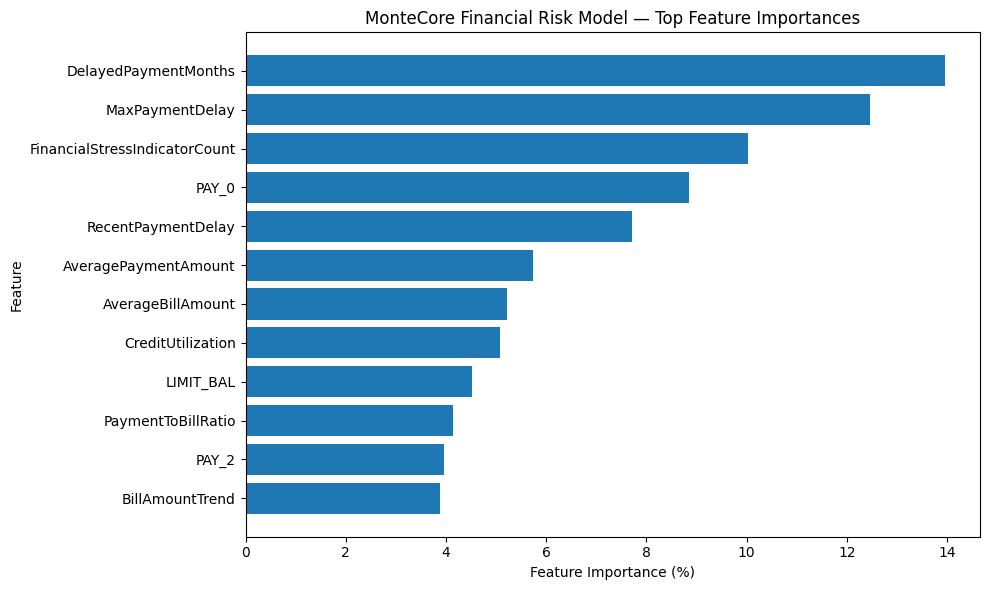

In [30]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(12)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["ImportancePercent"][::-1]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("MonteCore Financial Risk Model — Top Feature Importances")

plt.tight_layout()
plt.show()

In [31]:
def generate_risk_reasons(row):
    reasons = []

    if row["DelayedPaymentMonths"] >= 2:
        reasons.append("Repeated delayed payments")

    if row["MaxPaymentDelay"] >= 2:
        reasons.append("Severe historical payment delay")

    if row["RecentPaymentDelay"] >= 1:
        reasons.append("Recent payment delinquency")

    if row["CreditUtilization"] >= 0.80:
        reasons.append("High credit utilization")

    if row["PaymentToBillRatio"] < 0.10:
        reasons.append("Low payment-to-bill ratio")

    if row["RepaymentDeterioration"] > 0:
        reasons.append("Repayment behaviour deteriorating")

    if row["FinancialStressIndicatorCount"] >= 3:
        reasons.append("Multiple financial stress indicators")

    if len(reasons) == 0:
        reasons.append("No major rule-based stress indicator")

    return reasons


test_results["RiskReasons"] = test_results.apply(
    generate_risk_reasons,
    axis=1
)

test_results[
    [
        "DefaultProbability",
        "RiskLevel",
        "EarlyWarningFlag",
        "RiskReasons"
    ]
].head(10)

,DefaultProbability,RiskLevel,EarlyWarningFlag,RiskReasons
6907,0.265464,Low,0,[No major rule-based stress indicator]
24575,0.309089,Medium,0,[No major rule-based stress indicator]
26766,0.381280,Medium,0,"[High credit utilization, Low payment-to-bill ..."
2156,0.311544,Medium,0,"[High credit utilization, Low payment-to-bill ..."
3179,0.185287,Low,0,[No major rule-based stress indicator]
29382,0.471784,High,1,"[Repeated delayed payments, Severe historical ..."
24454,0.272755,Low,0,[Low payment-to-bill ratio]
23886,0.133210,Low,0,[No major rule-based stress indicator]
5504,0.244582,Low,0,[No major rule-based stress indicator]
29720,0.172086,Low,0,[Low payment-to-bill ratio]


In [32]:
high_risk_reason_counts = (
    test_results.loc[
        test_results["RiskLevel"] == "High",
        "RiskReasons"
    ]
    .explode()
    .value_counts()
)

print("Risk indicators among High-Risk customers")
print("-----------------------------------------")
print(high_risk_reason_counts)

print("\nPercentage of High-Risk customers with each indicator")
print("----------------------------------------------------")

high_risk_reason_percent = (
    high_risk_reason_counts
    / (test_results["RiskLevel"] == "High").sum()
    * 100
)

print(
    high_risk_reason_percent.round(2)
)

Risk indicators among High-Risk customers
-----------------------------------------
RiskReasons
Severe historical payment delay         1427
Low payment-to-bill ratio               1302
Recent payment delinquency              1173
Multiple financial stress indicators    1156
Repeated delayed payments               1062
Repayment behaviour deteriorating        991
High credit utilization                  500
No major rule-based stress indicator     134
Name: count, dtype: int64

Percentage of High-Risk customers with each indicator
----------------------------------------------------
RiskReasons
Severe historical payment delay         77.14
Low payment-to-bill ratio               70.38
Recent payment delinquency              63.41
Multiple financial stress indicators    62.49
Repeated delayed payments               57.41
Repayment behaviour deteriorating       53.57
High credit utilization                 27.03
No major rule-based stress indicator     7.24
Name: count, dtype: float64


In [33]:
high_risk_investigation = (
    test_results[
        test_results["EarlyWarningFlag"] == 1
    ]
    .copy()
)

# Convert model score to an easier-to-read percentage
high_risk_investigation["RiskScorePercent"] = (
    high_risk_investigation["DefaultProbability"] * 100
).round(2)

# Convert reason list into readable text
high_risk_investigation["RiskReasonSummary"] = (
    high_risk_investigation["RiskReasons"]
    .apply(lambda reasons: "; ".join(reasons))
)

# Highest-risk customers first
high_risk_investigation = (
    high_risk_investigation
    .sort_values(
        "DefaultProbability",
        ascending=False
    )
)

investigation_columns = [
    "RiskScorePercent",
    "RiskLevel",
    "ActualDefault",
    "DelayedPaymentMonths",
    "MaxPaymentDelay",
    "RecentPaymentDelay",
    "CreditUtilization",
    "PaymentToBillRatio",
    "FinancialStressIndicatorCount",
    "RiskReasonSummary"
]

print(
    "Customers in financial-risk investigation queue:",
    len(high_risk_investigation)
)

high_risk_investigation[
    investigation_columns
].head(15)

Customers in financial-risk investigation queue: 1850


,RiskScorePercent,RiskLevel,ActualDefault,DelayedPaymentMonths,MaxPaymentDelay,RecentPaymentDelay,CreditUtilization,PaymentToBillRatio,FinancialStressIndicatorCount,RiskReasonSummary
27536,96.70,High,1,6,3,3,0.009948,0.000000,4,Repeated delayed payments; Severe historical p...
29770,96.57,High,1,6,7,3,0.120000,0.000000,3,Repeated delayed payments; Severe historical p...
20721,96.56,High,1,6,7,3,0.120000,0.000000,3,Repeated delayed payments; Severe historical p...
28054,96.56,High,1,6,7,3,0.120000,0.000000,3,Repeated delayed payments; Severe historical p...
16554,96.40,High,1,6,7,3,0.230000,0.000000,3,Repeated delayed payments; Severe historical p...
16788,96.11,High,1,6,7,3,0.079300,0.000000,3,Repeated delayed payments; Severe historical p...
1956,95.98,High,1,6,2,2,0.011364,0.000000,3,Repeated delayed payments; Severe historical p...
28747,95.94,High,0,6,7,3,0.048000,0.000000,3,Repeated delayed payments; Severe historical p...
24397,95.60,High,1,6,3,3,0.052500,0.000000,3,Repeated delayed payments; Severe historical p...
11907,95.37,High,1,6,3,3,0.154947,0.051299,4,Repeated delayed payments; Severe historical p...


In [34]:
final_risk_results = test_results.copy()

final_risk_results["RiskScore"] = (
    final_risk_results["DefaultProbability"]
)

final_risk_results["RiskScorePercent"] = (
    final_risk_results["RiskScore"] * 100
).round(2)

final_risk_results["RiskReasonSummary"] = (
    final_risk_results["RiskReasons"]
    .apply(lambda reasons: "; ".join(reasons))
)

# Keep useful output columns
final_output_columns = [
    "ActualDefault",
    "RiskScore",
    "RiskScorePercent",
    "RiskLevel",
    "EarlyWarningFlag",
    "DelayedPaymentMonths",
    "MaxPaymentDelay",
    "RecentPaymentDelay",
    "CreditUtilization",
    "PaymentToBillRatio",
    "FinancialStressIndicatorCount",
    "RiskReasonSummary"
]

final_risk_results = final_risk_results[
    final_output_columns
].copy()

print("Final financial-risk dataset")
print("----------------------------")
print("Rows:", len(final_risk_results))
print("Columns:", len(final_risk_results.columns))

print("\nRisk distribution:")
print(
    final_risk_results["RiskLevel"]
    .value_counts()
    .sort_index()
)

print("\nEarly-warning distribution:")
print(
    final_risk_results["EarlyWarningFlag"]
    .value_counts()
    .sort_index()
)

final_risk_results.head()

Final financial-risk dataset
----------------------------
Rows: 6000
Columns: 12

Risk distribution:
RiskLevel
Low       2460
Medium    1690
High      1850
Name: count, dtype: int64

Early-warning distribution:
EarlyWarningFlag
0    4150
1    1850
Name: count, dtype: int64


,ActualDefault,RiskScore,RiskScorePercent,RiskLevel,EarlyWarningFlag,DelayedPaymentMonths,MaxPaymentDelay,RecentPaymentDelay,CreditUtilization,PaymentToBillRatio,FinancialStressIndicatorCount,RiskReasonSummary
6907,0,0.265464,26.55,Low,0,0,0,0,0.121113,1.003385,0,No major rule-based stress indicator
24575,0,0.309089,30.91,Medium,0,0,0,0,0.029660,1.561924,0,No major rule-based stress indicator
26766,0,0.381280,38.13,Medium,0,0,0,0,0.988530,0.039392,2,High credit utilization; Low payment-to-bill r...
2156,1,0.311544,31.15,Medium,0,0,0,0,0.935412,0.050182,2,High credit utilization; Low payment-to-bill r...
3179,0,0.185287,18.53,Low,0,0,0,0,0.021636,1.215185,0,No major rule-based stress indicator


In [35]:
# Restore original customer ID using the preserved test-set index
final_risk_results.insert(
    0,
    "CustomerID",
    df.loc[final_risk_results.index, "ID"].values
)

print("Customer IDs restored.")
print(
    "Unique CustomerIDs:",
    final_risk_results["CustomerID"].nunique()
)

print(
    "Duplicate CustomerIDs:",
    final_risk_results["CustomerID"].duplicated().sum()
)

final_risk_results.head()

Customer IDs restored.
Unique CustomerIDs: 6000
Duplicate CustomerIDs: 0


,CustomerID,ActualDefault,RiskScore,RiskScorePercent,RiskLevel,EarlyWarningFlag,DelayedPaymentMonths,MaxPaymentDelay,RecentPaymentDelay,CreditUtilization,PaymentToBillRatio,FinancialStressIndicatorCount,RiskReasonSummary
6907,6908,0,0.265464,26.55,Low,0,0,0,0,0.121113,1.003385,0,No major rule-based stress indicator
24575,24576,0,0.309089,30.91,Medium,0,0,0,0,0.029660,1.561924,0,No major rule-based stress indicator
26766,26767,0,0.381280,38.13,Medium,0,0,0,0,0.988530,0.039392,2,High credit utilization; Low payment-to-bill r...
2156,2157,1,0.311544,31.15,Medium,0,0,0,0,0.935412,0.050182,2,High credit utilization; Low payment-to-bill r...
3179,3180,0,0.185287,18.53,Low,0,0,0,0,0.021636,1.215185,0,No major rule-based stress indicator


In [36]:
from pathlib import Path

output_path = Path(
    "../data/processed/financial_risk_results.csv"
)

# Save without the pandas index
final_risk_results.to_csv(
    output_path,
    index=False
)

print("Financial-risk dataset saved successfully.")
print("Location:", output_path)
print("Rows saved:", len(final_risk_results))
print("Columns saved:", len(final_risk_results.columns))

Financial-risk dataset saved successfully.
Location: ..\data\processed\financial_risk_results.csv
Rows saved: 6000
Columns saved: 13


In [37]:
risk_export_check = pd.read_csv(
    "../data/processed/financial_risk_results.csv"
)

print("Export validation")
print("-----------------")

print("Shape:", risk_export_check.shape)

print(
    "Duplicate CustomerIDs:",
    risk_export_check["CustomerID"].duplicated().sum()
)

print(
    "Missing values:",
    risk_export_check.isna().sum().sum()
)

print("\nRisk distribution:")
print(
    risk_export_check["RiskLevel"]
    .value_counts()
)

print("\nEarly-warning distribution:")
print(
    risk_export_check["EarlyWarningFlag"]
    .value_counts()
    .sort_index()
)

Export validation
-----------------
Shape: (6000, 13)
Duplicate CustomerIDs: 0
Missing values: 0

Risk distribution:
RiskLevel
Low       2460
High      1850
Medium    1690
Name: count, dtype: int64

Early-warning distribution:
EarlyWarningFlag
0    4150
1    1850
Name: count, dtype: int64


In [38]:
import joblib
import json

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# 1. Save trained Random Forest
model_path = models_dir / "financial_risk_random_forest.joblib"

joblib.dump(
    rf_model,
    model_path
)

# 2. Save exact feature contract
features_path = models_dir / "financial_risk_features.json"

with open(features_path, "w") as f:
    json.dump(
        model_features,
        f,
        indent=4
    )

# 3. Save MonteCore operating policy
policy = {
    "early_warning_threshold": MONTECORE_RISK_THRESHOLD,

    "risk_bands": {
        "low": {
            "min": 0.0,
            "max_exclusive": 0.30
        },
        "medium": {
            "min": 0.30,
            "max_exclusive": 0.45
        },
        "high": {
            "min": 0.45,
            "max": 1.0
        }
    },

    "model_type": "RandomForestClassifier",

    "risk_score_note": (
        "Model score used for risk ranking. "
        "Raw scores have not been probability-calibrated."
    )
}

policy_path = models_dir / "financial_risk_policy.json"

with open(policy_path, "w") as f:
    json.dump(
        policy,
        f,
        indent=4
    )

print("Financial-risk artifacts saved successfully.")
print("Model:   ", model_path.name)
print("Features:", features_path.name)
print("Policy:  ", policy_path.name)

Financial-risk artifacts saved successfully.
Model:    financial_risk_random_forest.joblib
Features: financial_risk_features.json
Policy:   financial_risk_policy.json


In [39]:
import joblib
import json
import numpy as np

# Reload model
loaded_risk_model = joblib.load(
    "../models/financial_risk_random_forest.joblib"
)

# Reload feature contract
with open(
    "../models/financial_risk_features.json",
    "r"
) as f:
    loaded_risk_features = json.load(f)

# Reload policy
with open(
    "../models/financial_risk_policy.json",
    "r"
) as f:
    loaded_risk_policy = json.load(f)

print("Artifacts loaded successfully.")

print(
    "Feature count:",
    len(loaded_risk_features)
)

print(
    "Features match original:",
    loaded_risk_features == model_features
)

print(
    "Loaded early-warning threshold:",
    loaded_risk_policy["early_warning_threshold"]
)

# Recreate test feature matrix using saved feature contract
X_test_reload = X_test[loaded_risk_features].copy()

# Generate scores with reloaded model
reload_risk_scores = (
    loaded_risk_model.predict_proba(
        X_test_reload
    )[:, 1]
)

print(
    "Scores identical:",
    np.allclose(
        reload_risk_scores,
        y_prob_rf
    )
)

reload_flags = (
    reload_risk_scores
    >= loaded_risk_policy["early_warning_threshold"]
).astype(int)

print(
    "Reloaded warning flags:",
    reload_flags.sum()
)

print(
    "Original warning flags:",
    y_pred_montecore.sum()
)

print(
    "Warning flags identical:",
    np.array_equal(
        reload_flags,
        y_pred_montecore
    )
)

Artifacts loaded successfully.
Feature count: 19
Features match original: True
Loaded early-warning threshold: 0.45
Scores identical: True
Reloaded warning flags: 1850
Original warning flags: 1850
Warning flags identical: True
